<a href="https://www.kaggle.com/code/shamanthakreddymallu/s6e7-catboost?scriptVersionId=332581853" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Imports & Load

In [1]:
# PATHS
TRAIN_PATH    = '/kaggle/input/competitions/playground-series-s6e7/train.csv'
TEST_PATH     = '/kaggle/input/competitions/playground-series-s6e7/test.csv'
SAMPLE_PATH   = '/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv'
ORIGINAL_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/student_health_dataset_50k.csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                             classification_report)
from itertools import product
import warnings
warnings.filterwarnings('ignore')

train    = pd.read_csv(TRAIN_PATH)
test     = pd.read_csv(TEST_PATH)
original = pd.read_csv(ORIGINAL_PATH)

TARGET       = 'health_condition'
CLASS_COLORS = {'fit': '#55A868', 'at-risk': '#4C72B0', 'unhealthy': '#C44E52'}

CAT_COLS = ['diet_type', 'stress_level', 'sleep_quality',
            'physical_activity_level', 'smoking_alcohol', 'gender']
NUM_COLS = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
            'step_count', 'exercise_duration', 'water_intake']

for df in [train, test, original]:
    for c in CAT_COLS:
        df[c] = df[c].astype(str).str.strip().str.lower().replace('nan', np.nan)

original[TARGET] = original[TARGET].astype(str).str.strip().str.lower()
original = original.drop(columns=['student_id', 'timestamp'])

print(f'Train    : {train.shape}')
print(f'Test     : {test.shape}')
print(f'Original : {original.shape}')

Train    : (690088, 15)
Test     : (295753, 14)
Original : (50000, 14)


# Feature Engineering

Identical to the LightGBM notebook so OOF probabilities are blendable:
- Gate interactions: `stress_x_activity`, `stress_x_sleepq`, `stress_x_smoke`
- Boundary helpers: `sleep_lt6`/`sleep_ge7`, `sleep_dev`, activity composites, `bmi_band`

In [3]:
def engineer_features(df):
    df = df.copy()

    # ---- Gate interactions (the key features) ----
    df['stress_x_activity'] = (df['stress_level'].fillna('na') + '_' +
                               df['physical_activity_level'].fillna('na'))
    df['stress_x_sleepq']   = (df['stress_level'].fillna('na') + '_' +
                               df['sleep_quality'].fillna('na'))
    df['stress_x_smoke']    = (df['stress_level'].fillna('na') + '_' +
                               df['smoking_alcohol'].fillna('na'))

    # ---- Numeric boundary helpers ----
    df['sleep_lt6'] = (df['sleep_duration'] < 6).astype(float)
    df['sleep_lt6'] = df['sleep_lt6'].where(df['sleep_duration'].notna())
    df['sleep_ge7'] = (df['sleep_duration'] >= 7).astype(float)
    df['sleep_ge7'] = df['sleep_ge7'].where(df['sleep_duration'].notna())

    df['steps_x_exercise']    = df['step_count'] * df['exercise_duration']
    df['activity_efficiency'] = df['calorie_expenditure'] / df['step_count'].replace(0, np.nan)
    df['sleep_x_steps']       = df['sleep_duration'] * df['step_count']
    df['bmi_band']  = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100], labels=[0, 1, 2, 3]).astype(float)
    df['sleep_dev'] = (df['sleep_duration'] - 7.5).abs()

    return df

train    = engineer_features(train)
test     = engineer_features(test)
original = engineer_features(original)

ENGINEERED_CATS = ['stress_x_activity', 'stress_x_sleepq', 'stress_x_smoke']
ENGINEERED_NUMS = ['sleep_lt6', 'sleep_ge7', 'steps_x_exercise',
                   'activity_efficiency', 'sleep_x_steps', 'bmi_band', 'sleep_dev']

FEATURES  = NUM_COLS + CAT_COLS + ENGINEERED_CATS + ENGINEERED_NUMS
MODEL_CATS = CAT_COLS + ENGINEERED_CATS
print(f'{len(FEATURES)} features ({len(MODEL_CATS)} categorical)')

23 features (9 categorical)


## Categorical Handling — CatBoost

CatBoost requires categorical features as strings with no NaN — fill missing with an explicit `'missing'` token. Numeric NaNs are handled natively.

In [4]:
# CatBoost cat features: string dtype, NaN -> 'missing'
for df in [train, test, original]:
    for c in MODEL_CATS:
        df[c] = df[c].fillna('missing').astype(str)

print('Cat features ready:', MODEL_CATS)
print(train[MODEL_CATS].isna().sum().sum(), 'remaining NaN in cats (should be 0)')

Cat features ready: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'stress_x_activity', 'stress_x_sleepq', 'stress_x_smoke']
0 remaining NaN in cats (should be 0)


## Integrate Original Data

Same protocol as LightGBM: original rows appended to **training folds only**, validation always pure Kaggle.

In [5]:
USE_ORIGINAL = True

train['source']    = 'kaggle'
original['source'] = 'original'

train_augmented = pd.concat(
    [train[FEATURES + [TARGET, 'source']],
     original[FEATURES + [TARGET, 'source']] if USE_ORIGINAL else
     original[FEATURES + [TARGET, 'source']].iloc[0:0]],
    ignore_index=True
)

print(f'Augmented: {len(train_augmented):,} rows '
      f'({(train_augmented.source=="kaggle").sum():,} kaggle + '
      f'{(train_augmented.source=="original").sum():,} original)')

Augmented: 740,088 rows (690,088 kaggle + 50,000 original)


# Modeling — CatBoost, Stratified 5-Fold

- Same folds/seed as the LightGBM notebook so OOF arrays are blendable
- `auto_class_weights='Balanced'` mirrors LGBM's class_weight
- OOF + test probabilities saved to `oof_cat.npy` / `test_cat.npy`

In [6]:
le = LabelEncoder()
y_aug = le.fit_transform(train_augmented[TARGET])
print('Class encoding:', dict(zip(le.classes_, range(len(le.classes_)))))

N_FOLDS   = 5
SEED      = 42
N_CLASSES = 3

kag_idx  = np.where(train_augmented['source'] == 'kaggle')[0]
orig_idx = np.where(train_augmented['source'] == 'original')[0]

skf         = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
FOLD_SPLITS = list(skf.split(kag_idx, y_aug[kag_idx]))

CAT_PARAMS = dict(
    loss_function      = 'MultiClass',
    eval_metric        = 'MultiClass',
    iterations         = 6000,
    learning_rate      = 0.03,
    depth              = 7,
    l2_leaf_reg        = 3.0,
    random_strength    = 1.0,
    auto_class_weights = 'Balanced',
    random_seed        = SEED,
    od_type            = 'Iter',
    od_wait            = 200,
    verbose            = 0,
    allow_writing_files= False,
    task_type          = 'GPU',
    devices            = '0',
    border_count       = 254,
    one_hot_max_size   = 16, 
)

CAT_IDX = [FEATURES.index(c) for c in MODEL_CATS]

Class encoding: {'at-risk': 0, 'fit': 1, 'unhealthy': 2}


In [7]:
oof_probs  = np.zeros((len(kag_idx), N_CLASSES))
test_probs = np.zeros((len(test), N_CLASSES))
fold_scores, models, fi_list = [], [], []

test_pool = Pool(test[FEATURES], cat_features=CAT_IDX)

for fold, (tr_kag, val_kag) in enumerate(FOLD_SPLITS, 1):
    tr_idx  = np.concatenate([kag_idx[tr_kag], orig_idx])
    val_idx = kag_idx[val_kag]

    tr_pool  = Pool(train_augmented.iloc[tr_idx][FEATURES],  y_aug[tr_idx],  cat_features=CAT_IDX)
    val_pool = Pool(train_augmented.iloc[val_idx][FEATURES], y_aug[val_idx], cat_features=CAT_IDX)

    model = CatBoostClassifier(**CAT_PARAMS)
    model.fit(tr_pool, eval_set=val_pool, use_best_model=True)

    val_p = model.predict_proba(val_pool)
    oof_probs[val_kag] = val_p
    test_probs += model.predict_proba(test_pool) / N_FOLDS

    score = balanced_accuracy_score(y_aug[val_idx], val_p.argmax(1))
    fold_scores.append(score)
    models.append(model)
    fi_list.append(pd.Series(model.get_feature_importance(), index=FEATURES, name=f'fold{fold}'))
    print(f'Fold {fold}: balanced_acc = {score:.5f}  (best_iter={model.get_best_iteration()})')

y_kag = y_aug[kag_idx]
raw_oof_score = balanced_accuracy_score(y_kag, oof_probs.argmax(1))
print(f'\nRaw OOF (argmax): {raw_oof_score:.5f}')
print(f'CV mean         : {np.mean(fold_scores):.5f} +/- {np.std(fold_scores):.5f}')

np.save('oof_cat.npy', oof_probs)
np.save('test_cat.npy', test_probs)

Fold 1: balanced_acc = 0.94981  (best_iter=1074)
Fold 2: balanced_acc = 0.95067  (best_iter=1237)
Fold 3: balanced_acc = 0.94855  (best_iter=984)
Fold 4: balanced_acc = 0.94865  (best_iter=874)
Fold 5: balanced_acc = 0.94776  (best_iter=1031)

Raw OOF (argmax): 0.94909
CV mean         : 0.94909 +/- 0.00103


# Decision-Rule Optimization on OOF

Log-space grid (the ridge for this problem sits around 10-20x) + local refinement.

In [8]:
def optimize_class_weights(probs, y_true, coarse=31, refine=25):
    # class 0 = at-risk anchored at 1.0; search fit (1) and unhealthy (2)
    grid       = np.exp(np.linspace(np.log(0.5), np.log(40), coarse))
    best_score = balanced_accuracy_score(y_true, probs.argmax(1))
    best_w     = np.ones(3)
    for wf, wu in product(grid, grid):
        w = np.array([1.0, wf, wu])
        s = balanced_accuracy_score(y_true, (probs * w).argmax(1))
        if s > best_score:
            best_score, best_w = s, w
    ff = np.linspace(best_w[1] * 0.8, best_w[1] * 1.2, refine)
    fu = np.linspace(best_w[2] * 0.8, best_w[2] * 1.2, refine)
    for wf, wu in product(ff, fu):
        w = np.array([1.0, wf, wu])
        s = balanced_accuracy_score(y_true, (probs * w).argmax(1))
        if s > best_score:
            best_score, best_w = s, w
    return best_w, best_score

global_w, opt_oof_score = optimize_class_weights(oof_probs, y_kag)

print(f'Raw  OOF balanced accuracy : {raw_oof_score:.5f}')
print(f'Optimized weights          : {dict(zip(le.classes_, global_w.round(4)))}')
print(f'Opt. OOF balanced accuracy : {opt_oof_score:.5f}   (+{opt_oof_score - raw_oof_score:.5f})')

Raw  OOF balanced accuracy : 0.94909
Optimized weights          : {'at-risk': np.float64(1.0), 'fit': np.float64(0.9118), 'unhealthy': np.float64(1.0725)}
Opt. OOF balanced accuracy : 0.94920   (+0.00012)


# Segmented Decision Rule

separate weights for stress-present / stress-missing

In [9]:
train_kag = train.reset_index(drop=True)
stress_missing_tr = (train_kag['stress_level'] == 'missing').values
stress_missing_te = (test['stress_level'] == 'missing').values

seg_weights = {}
for name, mask in [('present', ~stress_missing_tr), ('missing', stress_missing_tr)]:
    w, s = optimize_class_weights(oof_probs[mask], y_kag[mask])
    seg_weights[name] = w
    print(f'{name:8s}: weights={w.round(3)}  seg_balanced_acc={s:.5f}')

preds_seg = np.empty(len(y_kag), dtype=int)
preds_seg[~stress_missing_tr] = (oof_probs[~stress_missing_tr] * seg_weights['present']).argmax(1)
preds_seg[stress_missing_tr]  = (oof_probs[stress_missing_tr]  * seg_weights['missing']).argmax(1)
seg_oof_score = balanced_accuracy_score(y_kag, preds_seg)
print(f'\nGlobal-weight OOF : {opt_oof_score:.5f}')
print(f'Segmented OOF     : {seg_oof_score:.5f}   ({seg_oof_score - opt_oof_score:+.5f})')

present : weights=[1.    0.912 1.072]  seg_balanced_acc=0.96145
missing : weights=[1.    1.475 1.46 ]  seg_balanced_acc=0.85998

Global-weight OOF : 0.94920
Segmented OOF     : 0.94927   (+0.00007)


# Post-Modeling Analysis

## OOF Score + Confusion Matrix

OOF Balanced Accuracy (optimized): 0.94920

              precision    recall  f1-score   support

     at-risk       0.99      0.93      0.96    592561
         fit       0.73      0.95      0.83     39803
   unhealthy       0.69      0.96      0.80     57724

    accuracy                           0.94    690088
   macro avg       0.80      0.95      0.86    690088
weighted avg       0.95      0.94      0.94    690088



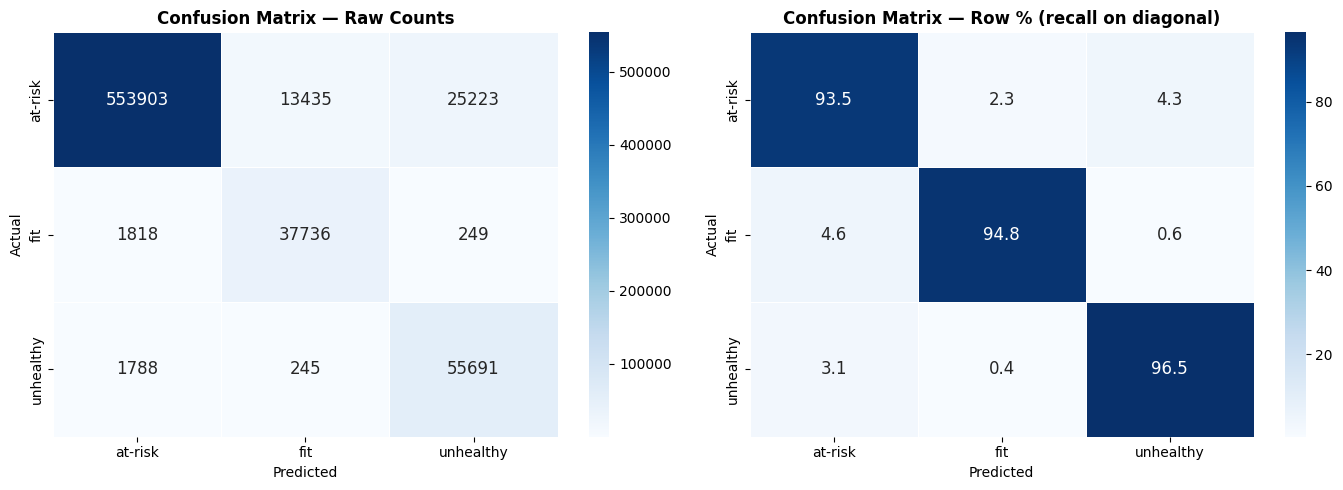

In [10]:
probs_w   = oof_probs * global_w
preds_kag = probs_w.argmax(1)

cm     = confusion_matrix(y_kag, preds_kag)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

print(f'OOF Balanced Accuracy (optimized): {opt_oof_score:.5f}')
print()
print(classification_report(y_kag, preds_kag, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[0], linewidths=0.5, annot_kws={'size': 12})
axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[1], linewidths=0.5, annot_kws={'size': 12})
axes[1].set_title('Confusion Matrix — Row % (recall on diagonal)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout(); plt.show()

## Subgroup Check — Stress-Missing Rows

In [11]:
train_kag = train.reset_index(drop=True)
stress_missing_mask = train_kag['stress_level'].isna().values

for name, mask in [('stress present', ~stress_missing_mask),
                   ('stress MISSING', stress_missing_mask)]:
    s = balanced_accuracy_score(y_kag[mask], preds_kag[mask])
    print(f'{name:16s}: balanced_acc = {s:.5f}   (n={mask.sum():,})')

stress present  : balanced_acc = 0.94920   (n=690,088)
stress MISSING  : balanced_acc = nan   (n=0)


## Feature Importance

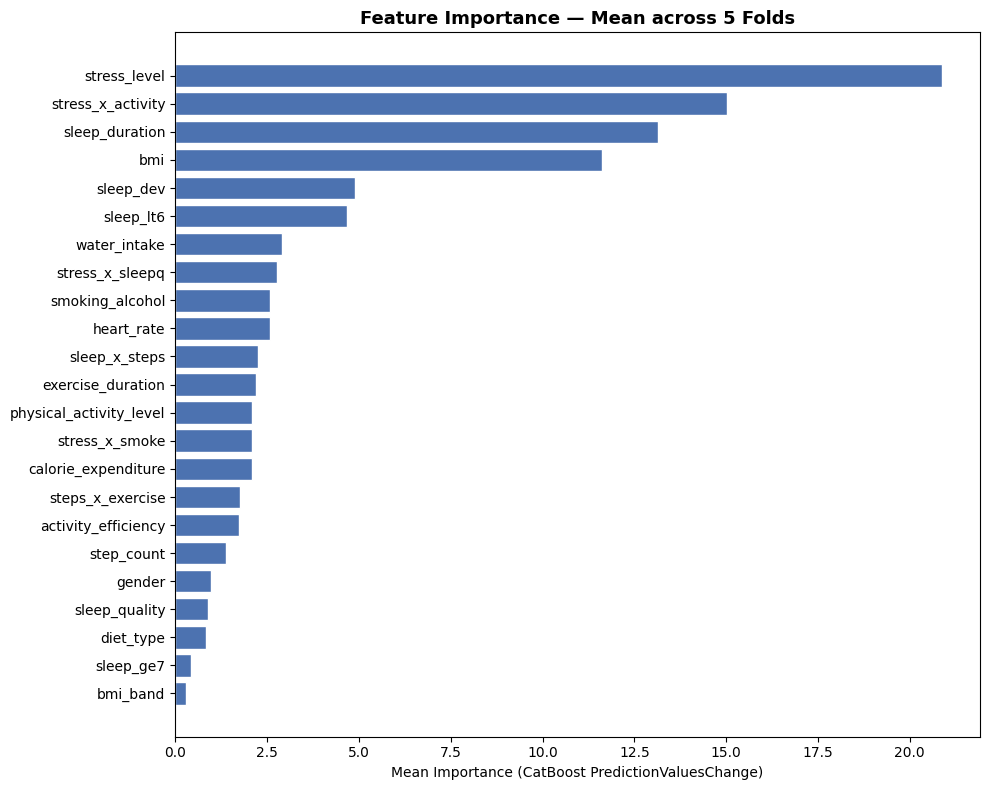

Top 15 features:
stress_level               20.87
stress_x_activity          15.02
sleep_duration             13.14
bmi                        11.62
sleep_dev                   4.91
sleep_lt6                   4.67
water_intake                2.91
stress_x_sleepq             2.77
smoking_alcohol             2.57
heart_rate                  2.57
sleep_x_steps               2.24
exercise_duration           2.20
physical_activity_level     2.09
stress_x_smoke              2.09
calorie_expenditure         2.08


In [12]:
fi_mean = pd.concat(fi_list, axis=1).mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(fi_mean.index[::-1], fi_mean.values[::-1], color='#4C72B0', edgecolor='white')
ax.set_xlabel('Mean Importance (CatBoost PredictionValuesChange)')
ax.set_title('Feature Importance — Mean across 5 Folds', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('Top 15 features:')
print(fi_mean.head(15).round(2).to_string())

## Error Analysis

In [13]:
error_df = train_kag[['stress_level', 'physical_activity_level', 'sleep_quality',
                       'sleep_duration', 'step_count', TARGET]].copy()
error_df['y_true']  = le.inverse_transform(y_kag)
error_df['y_pred']  = le.inverse_transform(preds_kag)
error_df['correct'] = error_df['y_true'] == error_df['y_pred']

errors = error_df[~error_df['correct']]
print(f'Total errors: {len(errors):,} ({len(errors)/len(error_df)*100:.2f}%)')
print('\nError breakdown by TRUE class:')
print(errors.groupby('y_true').size().to_string())
print('\nTop confusion cells (true -> pred):')
print(errors.groupby(['y_true', 'y_pred']).size().sort_values(ascending=False).head(6).to_string())
print('\nErrors by stress_level:')
print(errors.groupby(errors['stress_level'].astype(str)).size().to_string())

Total errors: 42,758 (6.20%)

Error breakdown by TRUE class:
y_true
at-risk      38658
fit           2067
unhealthy     2033

Top confusion cells (true -> pred):
y_true     y_pred   
at-risk    unhealthy    25223
           fit          13435
fit        at-risk       1818
unhealthy  at-risk       1788
fit        unhealthy      249
unhealthy  fit            245

Errors by stress_level:
stress_level
high       14415
low         5091
medium      1599
missing    21653


# Submission

Using SEGMENTED weights: present=[1.    0.912 1.072], missing=[1.    1.475 1.46 ]
Saved: submission.csv  (+ oof_cat.npy / test_cat.npy for blending)

Predicted class distribution (test):
at-risk      238993
unhealthy     34869
fit           21891

Train distribution for reference:
health_condition
at-risk      592561
unhealthy     57724
fit           39803


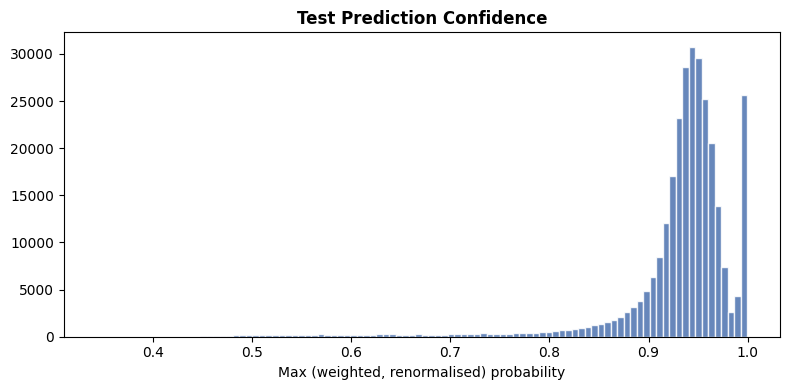

In [14]:
if seg_oof_score > opt_oof_score:
    test_w = np.empty_like(test_probs)
    test_w[~stress_missing_te] = test_probs[~stress_missing_te] * seg_weights['present']
    test_w[stress_missing_te]  = test_probs[stress_missing_te]  * seg_weights['missing']
    print(f'Using SEGMENTED weights: present={seg_weights["present"].round(3)}, missing={seg_weights["missing"].round(3)}')
else:
    test_w = test_probs * global_w
    print(f'Using GLOBAL weights: {global_w.round(3)}')

labels = le.inverse_transform(test_w.argmax(1))
sub = pd.read_csv(SAMPLE_PATH)
sub[TARGET] = labels

sub.to_csv('submission.csv', index=False)
print('Saved: submission.csv  (+ oof_cat.npy / test_cat.npy for blending)')
print('\nPredicted class distribution (test):')
print(pd.Series(labels).value_counts().to_string())
print('\nTrain distribution for reference:')
print(train[TARGET].value_counts().to_string())

fig, ax = plt.subplots(figsize=(8, 4))
norm_p = test_w / test_w.sum(1, keepdims=True)
ax.hist(norm_p.max(1), bins=100, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.set_xlabel('Max (weighted, renormalised) probability')
ax.set_title('Test Prediction Confidence', fontweight='bold')
plt.tight_layout(); plt.show()